# Этап 2. Спектральный анализ

ДПФ/БПФ речи, шума и смеси; влияние окна на утечку спектра; спектрограмма (STFT); вывод о полосах шума, мешающих речи. Соответствует разделу «Этап 2» файла `PLAN.md`, лекции 3--5 (часть 1).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
(PROJECT_ROOT / "results").mkdir(exist_ok=True)

SAMPLERATE = 16000   # Гц, частота дискретизации всего проекта
EPS = 1e-12          # защита от log(0) и деления на 0

## 0. Данные и вспомогательные функции этапа 1

Этап 2 использует те же данные и те же функции, что этап 1 (см. `stage01_data_vad.ipynb`); они повторены здесь, чтобы ноутбук запускался автономно.

In [2]:
def record_speech(duration_s: float, samplerate: int = SAMPLERATE) -> np.ndarray:
    import sounddevice as sd

    print(f"Идёт запись {duration_s:.1f} с — говорите после старта...")
    audio = sd.rec(int(duration_s * samplerate), samplerate=samplerate, channels=1, dtype="float32")
    sd.wait()
    print("Запись завершена.")
    return audio.flatten()


def load_or_record_speech(path: Path, duration_s: float = 6.0, samplerate: int = SAMPLERATE) -> np.ndarray:
    path = Path(path)
    if path.exists():
        speech, sr = sf.read(path, dtype="float32")
        if sr != samplerate:
            raise ValueError(f"{path}: частота дискретизации {sr} Гц, ожидалась {samplerate} Гц")
        return speech
    path.parent.mkdir(parents=True, exist_ok=True)
    speech = record_speech(duration_s, samplerate)
    sf.write(path, speech, samplerate)
    print(f"Сохранено: {path}")
    return speech


def _normalize_rms(x: np.ndarray) -> np.ndarray:
    """Приводит сигнал к единичной среднеквадратичной мощности: x / RMS(x), где
    RMS(x) = sqrt(mean(x**2)). После этого мощность сигнала равна ровно 1, и его
    дальше можно предсказуемо смешивать с другими сигналами произвольной исходной
    громкости — см. mix().
    """
    rms = np.sqrt(np.mean(x**2) + EPS)
    return x / rms


def synth_factory_noise(duration_s: float, samplerate: int = SAMPLERATE, seed: int | None = 0) -> np.ndarray:
    """Синтетический шум завода = гул моторов + широкополосный шум.

    Модель — сумма двух слагаемых, каждое приведено к единичной мощности и взято
    с своим весом:

        w(t) = 0.6 * (гул) + 0.4 * (широкополосный шум)

    Гул — это сумма нескольких гармоник основной частоты f0 (кратные частоты
    f0, 2f0, 3f0, ... возникают из-за периодического вращения вала двигателя или
    вентилятора; чем выше гармоника, тем меньше её амплитуда — так задан список
    [1.0, 0.6, 0.35, 0.2]). Широкополосный шум — обычный белый гауссовский шум
    (независимые нормальные случайные числа), он моделирует всё остальное:
    трение, вибрацию корпуса, электрические наводки — то, что не сводится к
    чистым тонам.
    """
    rng = np.random.default_rng(seed)
    n = int(duration_s * samplerate)
    t = np.arange(n) / samplerate

    base_freq = 90.0  # Гц — основная частота гула
    hum = np.zeros(n)
    for k, amp in enumerate([1.0, 0.6, 0.35, 0.2], start=1):
        hum += amp * np.sin(2 * np.pi * k * base_freq * t)

    white = rng.standard_normal(n)

    noise = 0.6 * _normalize_rms(hum) + 0.4 * _normalize_rms(white)
    return _normalize_rms(noise)


def mix(speech: np.ndarray, noise: np.ndarray, snr_db: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Смешивает речь и шум так, чтобы у смеси было ровно заданное ОСШ snr_db (дБ).

    Мощность сигнала — среднее значение его квадрата: P = mean(x**2). ОСШ по
    определению — это P_речь / P_шум, выраженное в децибелах:

        ОСШ(дБ) = 10 * log10(P_речь / P_шум).

    Готового шума с нужной мощностью у нас нет — есть некоторый noise с мощностью
    P_шум, и его нужно умножить на коэффициент k так, чтобы получить целевое ОСШ.
    Так как мощность растёт с КВАДРАТОМ амплитуды, после умножения на k мощность
    шума станет k**2 * P_шум. Подставляем это в определение ОСШ и решаем относительно k:

        snr_db = 10 * log10(P_речь / (k**2 * P_шум))
        10**(snr_db/10) = P_речь / (k**2 * P_шум)
        k**2 = P_речь / (P_шум * 10**(snr_db/10))
        k = sqrt(P_речь / (P_шум * 10**(snr_db/10)))

    Именно эта формула — ниже. Возвращает (смесь, речь, шум) — согласованно
    отмасштабированные, если потребовалась защита от клиппинга.
    """
    n = len(speech)
    reps = int(np.ceil(n / len(noise)))
    noise_full = np.tile(noise, reps)[:n]

    p_speech = np.mean(speech**2) + EPS
    p_noise = np.mean(noise_full**2) + EPS
    k = np.sqrt(p_speech / (p_noise * 10 ** (snr_db / 10)))
    noise_scaled = k * noise_full

    mixed = speech + noise_scaled
    peak = np.max(np.abs(mixed))
    if peak > 1.0:
        speech = speech / peak
        noise_scaled = noise_scaled / peak
        mixed = mixed / peak
    return mixed, speech, noise_scaled


def _frame_signal(signal: np.ndarray, frame_len: int, hop_len: int) -> np.ndarray:
    """Режет сигнал на короткие перекрывающиеся окна (кадры) по frame_len отсчётов
    со сдвигом hop_len между соседними кадрами. Это и есть операция "framing" —
    основа всех кратковременных оценок ниже (ОСШ, энергия для VAD): вместо одного
    числа на весь сигнал считаем его отдельно в каждом маленьком окне, чтобы видеть,
    как характеристика сигнала меняется во времени.
    """
    n_frames = max(1, 1 + (len(signal) - frame_len) // hop_len)
    frames = np.zeros((n_frames, frame_len))
    for i in range(n_frames):
        start = i * hop_len
        frames[i] = signal[start : start + frame_len]
    return frames


def energy_vad(
    signal: np.ndarray,
    samplerate: int = SAMPLERATE,
    win_ms: float = 25.0,
    hop_ms: float = 10.0,
    threshold_offset_db: float = 6.0,
    floor_percentile: float = 10.0,
) -> list[dict]:
    """Энергетический детектор речевой активности (Voice Activity Detection).

    Идея простая: пока говорят, энергия кадра заметно выше, чем в паузе, где
    остаётся только фоновый шум. Порог строится в два шага:

        1. noise_floor_db — floor_percentile-й процентиль энергии по всей записи,
           то есть уровень, ниже которого лежат самые тихие floor_percentile%
           кадров. Если пауз в записи заметно больше, чем активной речи, это
           разумная оценка "типичного уровня тишины", не требующая знать шум заранее.
        2. threshold_db = noise_floor_db + threshold_offset_db — к полу добавлен
           запас в decibel'ах, чтобы обычные колебания шума не принимались за речь.

    Кадр помечается как "speech", если его энергия (в дБ) выше threshold_db, и как
    "silence" иначе. Соседние кадры с одинаковой меткой объединяются в один
    сегмент. Возвращает таймлайн [{start, end, label}]."""
    frame_len = int(win_ms / 1000 * samplerate)
    hop_len = int(hop_ms / 1000 * samplerate)
    frames = _frame_signal(signal, frame_len, hop_len)
    energy_db = 10 * np.log10(np.mean(frames**2, axis=1) + EPS)

    noise_floor_db = np.percentile(energy_db, floor_percentile)
    threshold_db = noise_floor_db + threshold_offset_db
    is_speech = energy_db > threshold_db

    timeline = []
    frame_time = hop_len / samplerate
    start_idx = 0
    for i in range(1, len(is_speech) + 1):
        if i == len(is_speech) or is_speech[i] != is_speech[start_idx]:
            timeline.append(
                {
                    "start": round(start_idx * frame_time, 3),
                    "end": round(i * frame_time, 3),
                    "label": "speech" if is_speech[start_idx] else "silence",
                }
            )
            start_idx = i
    return timeline

In [3]:
speech = load_or_record_speech(PROJECT_ROOT / "data/samples/speech.wav")
noise = synth_factory_noise(len(speech) / SAMPLERATE)
mixed, speech_used, noise_used = mix(speech, noise, 5.0)
timeline = energy_vad(mixed)

## 1. ДПФ и БПФ

Дискретное преобразование Фурье последовательности $x[n]$, $n=0,\dots,N-1$:

$$X[k]=\sum_{n=0}^{N-1}x[n]\,e^{-2\pi i kn/N},\qquad k=0,\dots,N-1.$$

Номеру $k$ отвечает частота $f_k=k f_s/N$; шаг $\Delta f=f_s/N$ называется шириной бина. Для вещественного $x$ выполнено $X[N-k]=\overline{X[k]}$, поэтому достаточно $k=0,\dots,N/2$ (`np.fft.rfft`). БПФ -- алгоритм вычисления той же суммы за $O(N\log N)$ вместо $O(N^2)$; результат совпадает с ДПФ с точностью до ошибок округления.

In [4]:
def dft_naive(x: np.ndarray) -> np.ndarray:
    """ДПФ по определению, за O(N^2): X[k] = sum_n x[n] * exp(-2j*pi*k*n/N).

    Нужна только для проверки БПФ: строится матрица W[k, n] = exp(-2j*pi*k*n/N)
    и умножается на вектор x. Для N порядка 10^3 это ещё быстро, для N порядка
    10^5 -- уже нет (память N^2), поэтому в остальном коде используется БПФ.
    """
    n = len(x)
    k = np.arange(n)
    w = np.exp(-2j * np.pi * np.outer(k, k) / n)
    return w @ x

In [5]:
frame = mixed[:1024]
print("max |ДПФ по определению - БПФ| =", np.max(np.abs(dft_naive(frame) - np.fft.fft(frame))))

max |ДПФ по определению - БПФ| = 1.5231062234099123e-13


## 2. Спектры речи, шума и смеси

Спектр считается по всей записи с окном Ханна и нормировкой на сумму окна, чтобы пик синусоиды амплитуды $A$ имел уровень $20\log_{10}A$ независимо от окна.

### Окно Хэмминга: что это и зачем

Мы вырезаем из сигнала кусок длиной $N$ отсчётов. Резкий срез по краям -- как обрубить верёвку топором: на краях появляются «скачки», а скачки в спектре выглядят как лишние частоты (это и есть утечка). Окно -- это плавная «заслонка»: мы умножаем кусок на число от 0 до 1, которое в середине равно 1, а к краям спадает, так что срез получается мягким.

**Формула** (одна строка):

$$w[n]=0{,}54-0{,}46\cos\frac{2\pi n}{N-1},\qquad n=0,1,\dots,N-1.$$

Как читать: косинус при $n=0$ равен 1, поэтому $w[0]=0{,}54-0{,}46=0{,}08$ (край почти закрыт, но не до нуля); при $n=(N-1)/2$ косинус равен $-1$, и $w=0{,}54+0{,}46=1$ (середина полностью открыта).

| Окно | $w$ на краях | Главный лепесток | Боковые лепестки | Когда брать |
|---|---|---|---|---|
| Прямоугольное (нет окна) | 1 | самый узкий (2 бина) | высокие, $-13$ дБ | нужна максимальная резкость по частоте |
| Хэмминга | 0,08 | средний (4 бина) | ближние очень низкие, $-42$ дБ | нужно подавить ближнюю утечку |
| Ханна | 0 | средний (4 бина) | ниже всех вдали от пика | нужно подавить дальнюю утечку |



совпадает с np.hamming: True
w[0] = 0.08, w[N/2] ~ 1.00


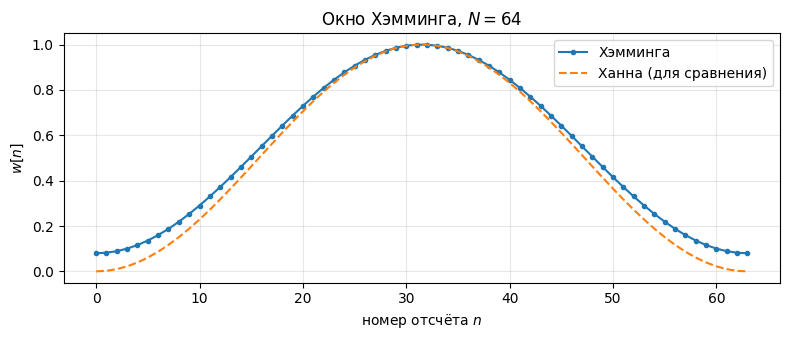

In [6]:
def hamming_window(n_points):
    """Окно Хэмминга w[n] = 0.54 - 0.46 * cos(2*pi*n / (N - 1)), n = 0..N-1."""
    n = np.arange(n_points)
    return 0.54 - 0.46 * np.cos(2 * np.pi * n / (n_points - 1))


N_DEMO = 64
w_hamming = hamming_window(N_DEMO)
print("совпадает с np.hamming:", np.allclose(w_hamming, np.hamming(N_DEMO)))
print(f"w[0] = {w_hamming[0]:.2f}, w[N/2] ~ {w_hamming.max():.2f}")

plt.figure(figsize=(8, 3.5))
plt.plot(w_hamming, "o-", markersize=3, label="Хэмминга")
plt.plot(np.hanning(N_DEMO), "--", label="Ханна (для сравнения)")
plt.xlabel("номер отсчёта $n$")
plt.ylabel("$w[n]$")
plt.title(f"Окно Хэмминга, $N={N_DEMO}$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Как выглядит спектр окна Хэмминга

**Идея на пальцах.** Окно -- тоже сигнал, и у него есть свой спектр. Он выглядит как «горка» посередине (главный лепесток) и маленькие «холмики» по бокам (боковые лепестки). Именно этот узор накладывается на каждую линию спектра сигнала: высота боковых холмиков и есть уровень утечки.

**Откуда берётся форма.** Окно Хэмминга -- это сумма трёх простых частей: постоянной $0{,}54$ и двух «волн» косинуса. Постоянная даёт большую горку $D(\omega)$ (её называют ядром Дирихле, это спектр прямоугольного окна). Косинус даёт две такие же горки поменьше, сдвинутые вправо и влево на 1 бин. Складываем три горки -- получается спектр окна. Сдвинутые копии подобраны так, что их холмики попадают в «ямы» и на холмики центральной горки и гасят их. Поэтому боковые лепестки становятся низкими.

**Формула** (для тех, кто хочет строго). Для $\omega_0=\frac{2\pi}{N-1}$ модуль спектра равен

$$|W(\omega)|=\left|\,0{,}54\,D(\omega)+0{,}23\,\bigl[D(\omega-\omega_0)+D(\omega+\omega_0)\bigr]\right|,\qquad D(\omega)=\frac{\sin(N\omega/2)}{\sin(\omega/2)}.$$

Здесь $0{,}23=0{,}46/2$. Знак «плюс» перед скобкой в такой записи (без фазового множителя) появляется из-за того, что сдвинутые копии имеют дополнительную фазу $\pi$; в полной комплексной записи перед ними стоит минус.

**Ключевые числа.**
- Высота главной горки $W(0)=\sum_n w[n]\approx0{,}54\,N$. Именно на эту величину делит нормировка в `amplitude_spectrum_db`, чтобы пик синусоиды не зависел от окна.
- Ширина главной горки по нулям около 4 бинов.
- Что показывают графики ниже: слева -- из чего складывается спектр (центральная горка, сдвинутая горка и их сумма), справа -- готовый спектр в дБ для трёх окон, на нём видно, что у Хэмминга боковые холмики самые низкие вблизи пика.

формула совпадает с БПФ: True
W(0) = 34.10  (0.54*N = 34.56)


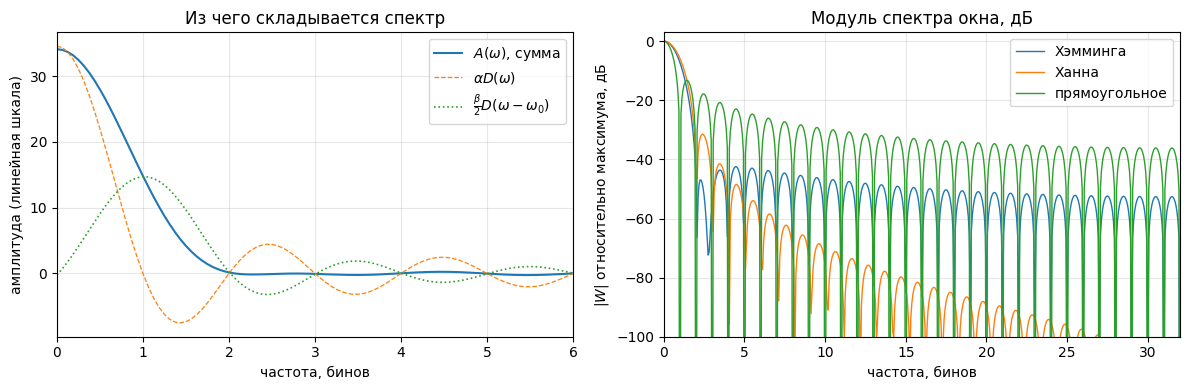

In [7]:
def dirichlet_ratio(omega, n_points):
    """sin(N*w/2) / sin(w/2), в нуле доопределено пределом N."""
    num = np.sin(n_points * omega / 2)
    den = np.sin(omega / 2)
    return np.where(np.abs(den) < 1e-12, n_points, num / np.where(np.abs(den) < 1e-12, 1, den))


def hamming_spectrum_analytic(omega, n_points, alpha=0.54, beta=0.46):
    """Безфазовая амплитуда A(w) окна Хэмминга по формуле через ядра Дирихле."""
    w0 = 2 * np.pi / (n_points - 1)
    return (
        alpha * dirichlet_ratio(omega, n_points)
        + beta / 2 * (dirichlet_ratio(omega - w0, n_points) + dirichlet_ratio(omega + w0, n_points))
    )


PAD = 16
n_fft = N_DEMO * PAD
omega = 2 * np.pi * np.fft.rfftfreq(n_fft)          # рад/отсчёт, 0..pi
bins = omega * N_DEMO / (2 * np.pi)                 # частота в бинах ДПФ длины N

spec_fft = np.abs(np.fft.rfft(w_hamming, n_fft))
spec_formula = np.abs(hamming_spectrum_analytic(omega, N_DEMO))
print("формула совпадает с БПФ:", np.allclose(spec_fft, spec_formula))
print(f"W(0) = {spec_fft[0]:.2f}  (0.54*N = {0.54 * N_DEMO:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

w0 = 2 * np.pi / (N_DEMO - 1)
axes[0].plot(bins, hamming_spectrum_analytic(omega, N_DEMO), label=r"$A(\omega)$, сумма", linewidth=1.5)
axes[0].plot(bins, 0.54 * dirichlet_ratio(omega, N_DEMO), "--", label=r"$\alpha D(\omega)$", linewidth=0.9)
axes[0].plot(bins, 0.23 * dirichlet_ratio(omega - w0, N_DEMO), ":", label=r"$\frac{\beta}{2}D(\omega-\omega_0)$", linewidth=1.2)
axes[0].set_xlim(0, 6)
axes[0].set_xlabel("частота, бинов")
axes[0].set_ylabel("амплитуда (линейная шкала)")
axes[0].set_title("Из чего складывается спектр")
axes[0].grid(alpha=0.3)
axes[0].legend()

for name, win in (("Хэмминга", w_hamming), ("Ханна", np.hanning(N_DEMO)), ("прямоугольное", np.ones(N_DEMO))):
    s = np.abs(np.fft.rfft(win, n_fft))
    axes[1].plot(bins, 20 * np.log10(s / s.max() + EPS), label=name, linewidth=1)
axes[1].set_xlim(0, N_DEMO / 2)
axes[1].set_ylim(-100, 3)
axes[1].set_xlabel("частота, бинов")
axes[1].set_ylabel("$|W|$ относительно максимума, дБ")
axes[1].set_title("Модуль спектра окна, дБ")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

In [8]:
WINDOWS = {
    "прямоугольное": lambda n: np.ones(n),
    "Хэмминга": lambda n: np.hamming(n),
    "Ханна": lambda n: np.hanning(n),
}


def amplitude_spectrum_db(x: np.ndarray, window: np.ndarray, samplerate: int = SAMPLERATE) -> tuple[np.ndarray, np.ndarray]:
    """Односторонний амплитудный спектр (дБ) вещественного сигнала.

    Сигнал умножается на окно и нормируется на сумму окна: |X[k]| * 2 / sum(w).
    Такая нормировка (когерентное усиление окна) делает пик синусоиды амплитуды A
    равным A независимо от типа окна, поэтому спектры с разными окнами можно
    честно сравнивать по высоте. Возвращает (частоты в Гц, уровень в дБ).
    """
    spec = np.fft.rfft(x * window)
    amp = 2 * np.abs(spec) / np.sum(window)
    freqs = np.fft.rfftfreq(len(x), 1 / samplerate)
    return freqs, 20 * np.log10(amp + EPS)


def plot_spectra(speech, noise, mixed, out: Path, samplerate: int = SAMPLERATE) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, sharey=True)
    for ax, sig, name, color in zip(axes, (speech, noise, mixed), ("чистая речь", "шум", "смесь"), ("tab:blue", "tab:red", "tab:green")):
        f, db = amplitude_spectrum_db(sig, np.hanning(len(sig)), samplerate)
        ax.plot(f, db, linewidth=0.5, color=color)
        ax.set_ylabel("уровень, дБ")
        ax.set_title(f"Спектр: {name} (окно Ханна, ДПФ по всей записи)")
        ax.set_xlim(0, samplerate / 2)
        ax.set_ylim(-120, None)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("частота, Гц")
    fig.tight_layout()
    fig.savefig(out, dpi=130)
    plt.show()

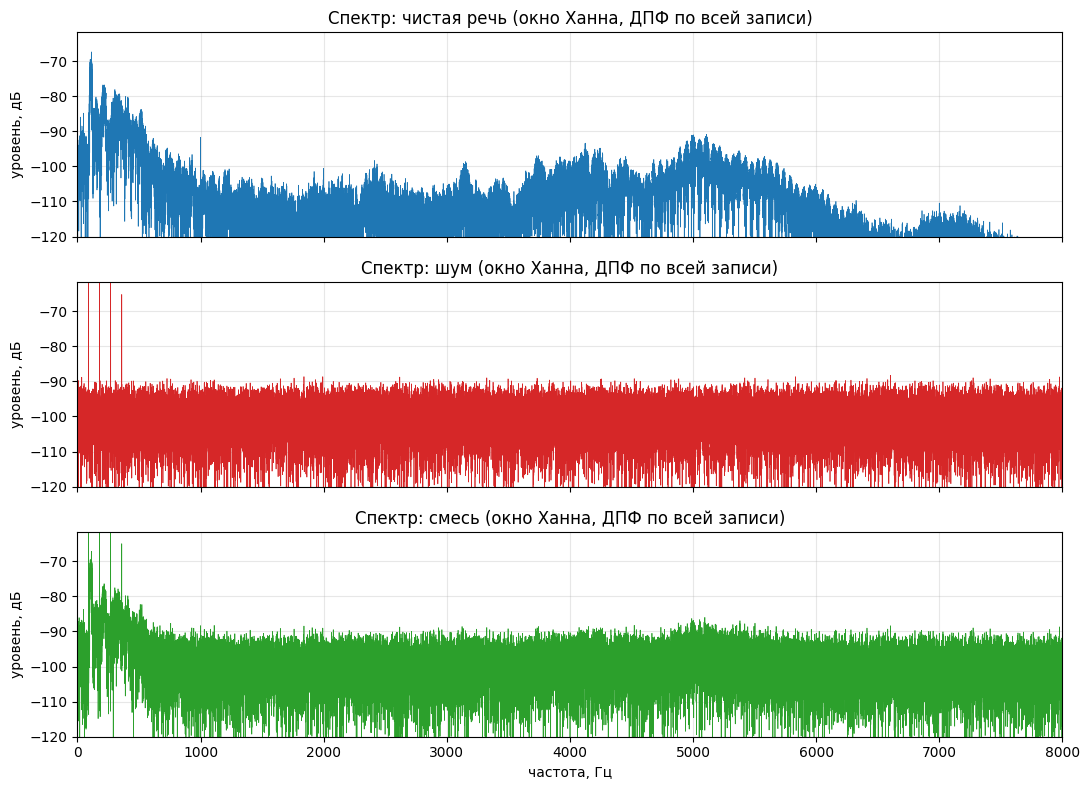

In [9]:
plot_spectra(speech_used, noise_used, mixed, PROJECT_ROOT / "results/stage02_spectra.png")

Наблюдения: энергия речи сосредоточена ниже $\approx 600$ Гц с пологим спадом; шум -- четыре узкие линии на $90,180,270,360$ Гц (гул) над ровным «полом» белого шума. В смеси линии гула перекрывают самый мощный участок речи.

## 3. Окна и утечка спектра

ДПФ конечного отрезка эквивалентно умножению бесконечного сигнала на окно $w[n]$; по теореме о свёртке спектр отрезка -- свёртка истинного спектра со спектром окна $W(f)$. Если частота синусоиды не кратна $f_s/N$ (период не укладывается в окно целое число раз), энергия «растекается» по соседним бинам -- это утечка. Окно характеризуют шириной главного лепестка (разрешение по частоте) и уровнем боковых лепестков (утечка): чем ниже боковые, тем шире главный.

Для теоремы о свёртке $\mathcal F\{x\cdot w\}=X * W$ требуется, чтобы $x$ и $w$ были определены на одной сетке отсчётов той же длины $N$.

In [10]:
def window_metrics(window: np.ndarray, oversample: int = 64) -> dict:
    """Числовые характеристики окна по его спектру (с дополнением нулями).

    - main_lobe_bins: ширина главного лепестка по нулям, в бинах ДПФ (1 бин = fs/N);
    - peak_sidelobe_db: уровень наибольшего бокового лепестка относительно главного;
    - decay: не считается, см. график.
    """
    n = len(window)
    spec = np.abs(np.fft.rfft(window, n * oversample))
    spec_db = 20 * np.log10(spec / spec.max() + EPS)
    # первый локальный минимум -- край главного лепестка
    i = 1
    while i < len(spec) - 1 and not (spec[i] <= spec[i - 1] and spec[i] <= spec[i + 1]):
        i += 1
    main_lobe_bins = 2 * i / oversample
    return {
        "main_lobe_bins": round(main_lobe_bins, 2),
        "peak_sidelobe_db": round(float(spec_db[i:].max()), 1),
    }


def leakage_demo(n: int = 1024, samplerate: int = SAMPLERATE, bin_offset: float = 0.5) -> dict:
    """Утечка спектра на синусоиде, частота которой лежит МЕЖДУ бинами ДПФ.

    Частота f = (k0 + bin_offset) * fs / N. При bin_offset = 0 период целиком
    укладывается в окно, и окно не портит картину; при 0.5 -- худший случай.
    Возвращает словарь {имя окна: (частоты, уровень дБ)}.
    """
    k0 = 100
    f = (k0 + bin_offset) * samplerate / n
    t = np.arange(n) / samplerate
    tone = np.sin(2 * np.pi * f * t)
    return {name: amplitude_spectrum_db(tone, w(n), samplerate) for name, w in WINDOWS.items()}


def plot_leakage(demo: dict, out: Path) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, (f, db) in demo.items():
        axes[0].plot(f, db, label=name, linewidth=0.9)
        axes[1].plot(f, db, label=name, linewidth=0.9)
    axes[0].set_title("Утечка спектра: синусоида между бинами, N = 1024")
    axes[1].set_title("Окрестность пика")
    axes[1].set_xlim(1400, 1850)
    for ax in axes:
        ax.set_xlabel("частота, Гц")
        ax.set_ylabel("уровень, дБ")
        ax.set_ylim(-140, 5)
        ax.grid(alpha=0.3)
    axes[0].legend()
    fig.tight_layout()
    fig.savefig(out, dpi=130)
    plt.show()

прямоугольное  главный лепесток 2.0 бин., боковой -13.3 дБ
Хэмминга       главный лепесток 4.16 бин., боковой -42.4 дБ
Ханна          главный лепесток 4.06 бин., боковой -31.5 дБ


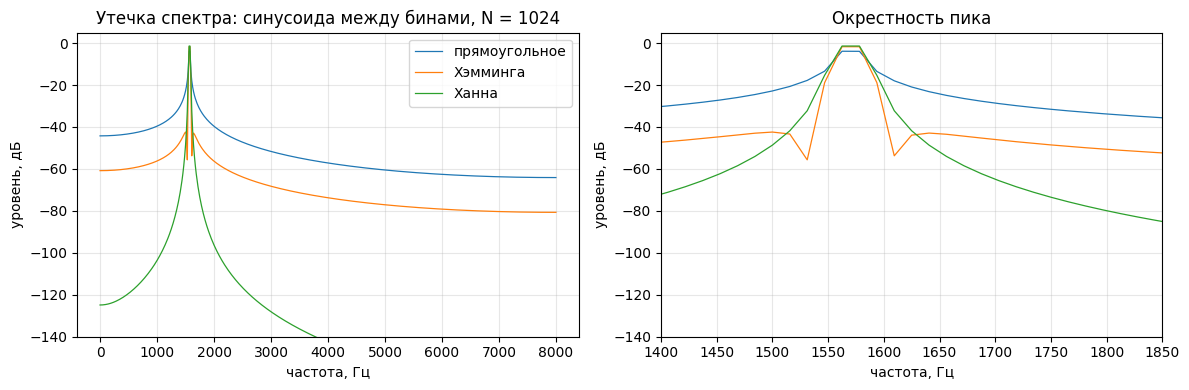

In [11]:
metrics = {name: window_metrics(w(64)) for name, w in WINDOWS.items()}
for name, m in metrics.items():
    print(f"{name:14s} главный лепесток {m['main_lobe_bins']} бин., боковой {m['peak_sidelobe_db']} дБ")
plot_leakage(leakage_demo(), PROJECT_ROOT / "results/stage02_window_leakage.png")

| Окно | Главный лепесток, бинов | Наибольший боковой, дБ | Спад боковых |
|---|---|---|---|
| Прямоугольное | 2 | $-13{,}3$ | медленный, 6 дБ/окт |
| Хэмминга | 4 | $-42{,}4$ | медленный, 6 дБ/окт |
| Ханна | 4 | $-31{,}5$ | быстрый, 18 дБ/окт |

Для речи в присутствии сильных гармоник гула нужно окно с малой утечкой, иначе линии 90--360 Гц «зальют» соседние слабые компоненты; поэтому далее используется окно Ханна (при том же главном лепестке, что у Хэмминга, у него значительно быстрее спад дальних боковых лепестков).

## 4. Спектрограмма и компромисс разрешений

STFT: $X[m,k]=\sum_{n}x[n+mH]\,w[n]\,e^{-2\pi i kn/L}$, где $L$ -- длина кадра, $H$ -- шаг. Разрешение по частоте $\Delta f=f_s/L$, по времени $\approx L/f_s$; одновременно улучшить оба нельзя (принцип неопределённости Габора--Гейзенберга: $\Delta t\,\Delta f\ge\text{const}$).

In [12]:
def stft(
    x: np.ndarray,
    samplerate: int = SAMPLERATE,
    win_ms: float = 32.0,
    hop_ms: float = 8.0,
    window: str = "Ханна",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Кратковременное преобразование Фурье: оконное БПФ по перекрывающимся кадрам.

    Возвращает (частоты, времена центров кадров, комплексная матрица [частота, кадр]).
    Кадрирование -- _frame_signal из этапа 1; длина БПФ равна длине кадра.
    """
    frame_len = int(win_ms / 1000 * samplerate)
    hop_len = int(hop_ms / 1000 * samplerate)
    frames = _frame_signal(x, frame_len, hop_len) * WINDOWS[window](frame_len)
    spec = np.fft.rfft(frames, axis=1).T
    freqs = np.fft.rfftfreq(frame_len, 1 / samplerate)
    times = (np.arange(spec.shape[1]) * hop_len + frame_len / 2) / samplerate
    return freqs, times, spec


def power_db(spec: np.ndarray) -> np.ndarray:
    return 10 * np.log10(np.abs(spec) ** 2 + EPS)


def plot_spectrogram(mixed, timeline, out: Path, samplerate: int = SAMPLERATE) -> None:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    freqs, times, spec = stft(mixed, samplerate)
    db = power_db(spec)
    im = ax.pcolormesh(times, freqs, db, shading="auto", vmin=db.max() - 90, vmax=db.max(), cmap="magma")
    for seg in timeline:
        if seg["label"] == "speech":
            ax.axvspan(seg["start"], seg["end"], ymin=0.96, ymax=1.0, color="cyan")
    ax.set_xlabel("время, с")
    ax.set_ylabel("частота, Гц")
    ax.set_title("Спектрограмма смеси (окно Ханна 32 мс, шаг 8 мс); голубая полоса сверху -- речь по VAD")
    fig.colorbar(im, ax=ax, label="мощность, дБ")
    fig.tight_layout()
    fig.savefig(out, dpi=130)
    plt.show()


def plot_resolution(mixed, out: Path, samplerate: int = SAMPLERATE) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, win_ms in zip(axes, (8.0, 32.0, 128.0)):
        freqs, times, spec = stft(mixed, samplerate, win_ms=win_ms, hop_ms=win_ms / 4)
        db = power_db(spec)
        ax.pcolormesh(times, freqs, db, shading="auto", vmin=db.max() - 90, vmax=db.max(), cmap="magma")
        ax.set_title(rf"Окно {win_ms:.0f} мс: $\Delta f$ = {samplerate / int(win_ms / 1000 * samplerate):.0f} Гц")
        ax.set_xlabel("время, с")
    axes[0].set_ylabel("частота, Гц")
    fig.tight_layout()
    fig.savefig(out, dpi=130)
    plt.show()

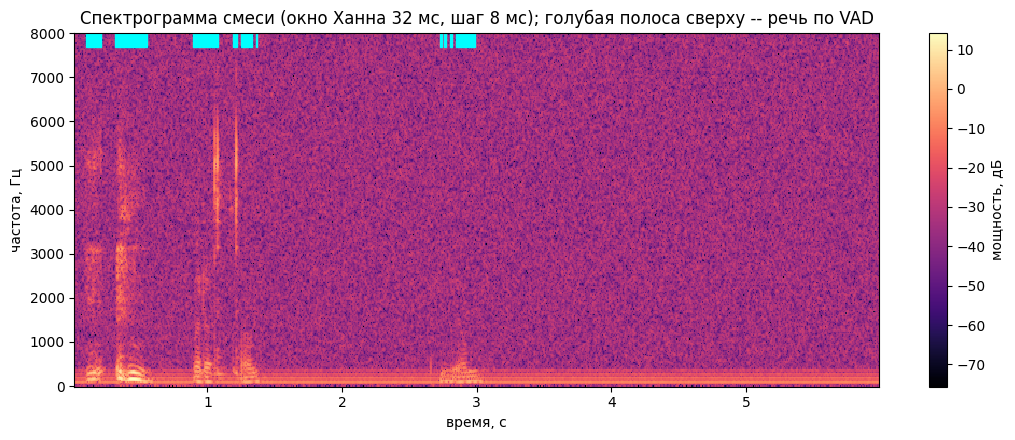

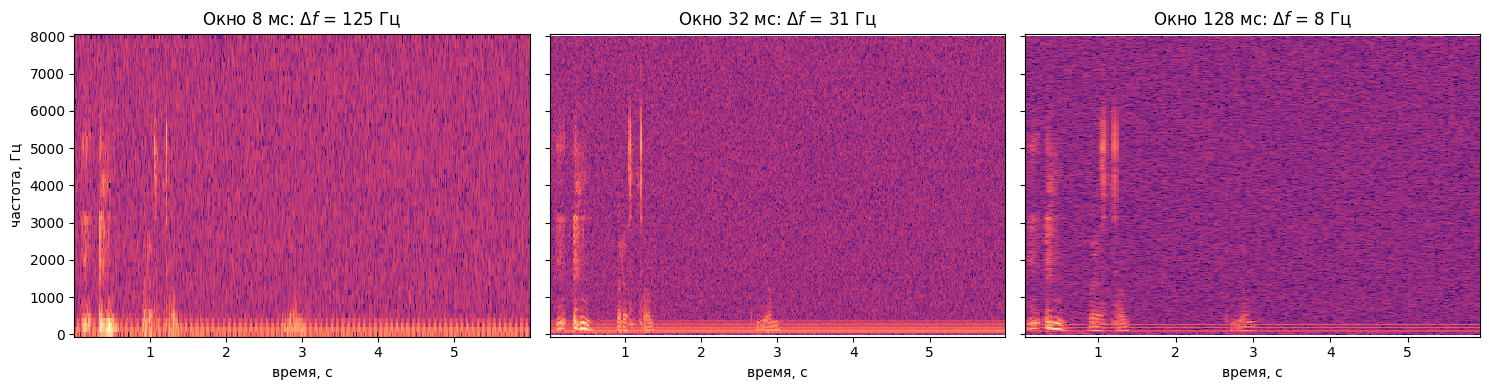

In [13]:
timeline = energy_vad(mixed)
plot_spectrogram(mixed, timeline, PROJECT_ROOT / "results/stage02_spectrogram.png")
plot_resolution(mixed, PROJECT_ROOT / "results/stage02_resolution.png")

Окно 8 мс ($\Delta f=125$ Гц) не разделяет гармоники гула и размывает их в сплошную полосу; окно 128 мс ($\Delta f\approx 8$ Гц) разделяет линии, но размазывает быстрые переходы речи по времени. Окно 32 мс -- разумный компромисс для речи (длительность квазистационарности $20$--$40$ мс), его и берём для следующих этапов.

## 5. ОСШ по частотным полосам

Мощность в полосе -- среднее по речевым кадрам (по VAD этапа 1) суммы $|X[m,k]|^2$ по бинам полосы; ОСШ в полосе -- отношение мощностей речи и шума в дБ.

In [14]:
def vad_frame_mask(timeline: list[dict], times: np.ndarray) -> np.ndarray:
    """Булева маска «кадр STFT попал в речевой сегмент VAD» по времени центра кадра."""
    mask = np.zeros(len(times), dtype=bool)
    for seg in timeline:
        if seg["label"] == "speech":
            mask |= (times >= seg["start"]) & (times < seg["end"])
    return mask


def band_snr_table(
    speech: np.ndarray,
    noise: np.ndarray,
    speech_mask: np.ndarray,
    samplerate: int = SAMPLERATE,
    edges_hz: tuple[int, ...] = (0, 100, 200, 300, 400, 600, 800, 1000, 1500, 2000, 3000, 4000, 6000, 8000),
) -> list[dict]:
    """Мощности речи и шума по частотным полосам и ОСШ в каждой полосе.

    Мощность в полосе -- среднее по кадрам суммы |STFT|^2 по бинам полосы; для
    речи усреднение только по кадрам, отмеченным VAD как речь (speech_mask), иначе
    паузы занизили бы оценку. Шум усредняется по тем же кадрам, чтобы ОСШ
    отвечало тому, что реально мешает во время речи.
    """
    freqs, _, s_spec = stft(speech, samplerate)
    _, _, n_spec = stft(noise, samplerate)
    m = min(s_spec.shape[1], len(speech_mask))
    s_pow = (np.abs(s_spec[:, :m]) ** 2)[:, speech_mask[:m]]
    n_pow = (np.abs(n_spec[:, :m]) ** 2)[:, speech_mask[:m]]

    rows = []
    for lo, hi in zip(edges_hz[:-1], edges_hz[1:]):
        sel = (freqs >= lo) & (freqs < hi) if hi < samplerate / 2 else (freqs >= lo)
        ps = s_pow[sel].sum(axis=0).mean()
        pn = n_pow[sel].sum(axis=0).mean()
        rows.append(
            {
                "band_hz": [lo, hi],
                "speech_db": round(float(10 * np.log10(ps + EPS)), 1),
                "noise_db": round(float(10 * np.log10(pn + EPS)), 1),
                "snr_db": round(float(10 * np.log10((ps + EPS) / (pn + EPS))), 1),
            }
        )
    return rows


def plot_band_snr(rows: list[dict], out: Path) -> None:
    labels = [f"{r['band_hz'][0]}-{r['band_hz'][1]}" for r in rows]
    x = np.arange(len(rows))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    ax1.bar(x - 0.2, [r["speech_db"] for r in rows], 0.4, label="речь", color="tab:blue")
    ax1.bar(x + 0.2, [r["noise_db"] for r in rows], 0.4, label="шум", color="tab:red")
    ax1.set_ylabel("мощность в полосе, дБ")
    ax1.legend()
    ax1.grid(alpha=0.3)
    snr = np.array([r["snr_db"] for r in rows])
    ax2.bar(x, snr, color=np.where(snr < 0, "tab:red", "tab:green"))
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_ylabel("ОСШ в полосе, дБ")
    ax2.set_xlabel("полоса, Гц")
    ax2.set_xticks(x, labels, rotation=45)
    ax2.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out, dpi=130)
    plt.show()

    0-100   Гц: речь   -5.3 дБ, шум   -7.9 дБ, ОСШ    2.6 дБ
  100-200   Гц: речь    6.9 дБ, шум  -10.8 дБ, ОСШ   17.7 дБ
  200-300   Гц: речь   -0.4 дБ, шум  -15.4 дБ, ОСШ   15.1 дБ
  300-400   Гц: речь    1.8 дБ, шум  -20.7 дБ, ОСШ   22.5 дБ
  400-600   Гц: речь   -4.6 дБ, шум  -24.8 дБ, ОСШ   20.2 дБ
  600-800   Гц: речь  -14.6 дБ, шум  -25.3 дБ, ОСШ   10.7 дБ
  800-1000  Гц: речь  -19.6 дБ, шум  -25.9 дБ, ОСШ    6.3 дБ
 1000-1500  Гц: речь  -19.8 дБ, шум  -21.1 дБ, ОСШ    1.3 дБ
 1500-2000  Гц: речь  -14.8 дБ, шум  -20.8 дБ, ОСШ    6.0 дБ
 2000-3000  Гц: речь   -9.8 дБ, шум  -18.2 дБ, ОСШ    8.4 дБ
 3000-4000  Гц: речь   -9.2 дБ, шум  -18.4 дБ, ОСШ    9.2 дБ
 4000-6000  Гц: речь   -4.1 дБ, шум  -14.9 дБ, ОСШ   10.9 дБ
 6000-8000  Гц: речь  -23.0 дБ, шум  -15.1 дБ, ОСШ   -7.9 дБ


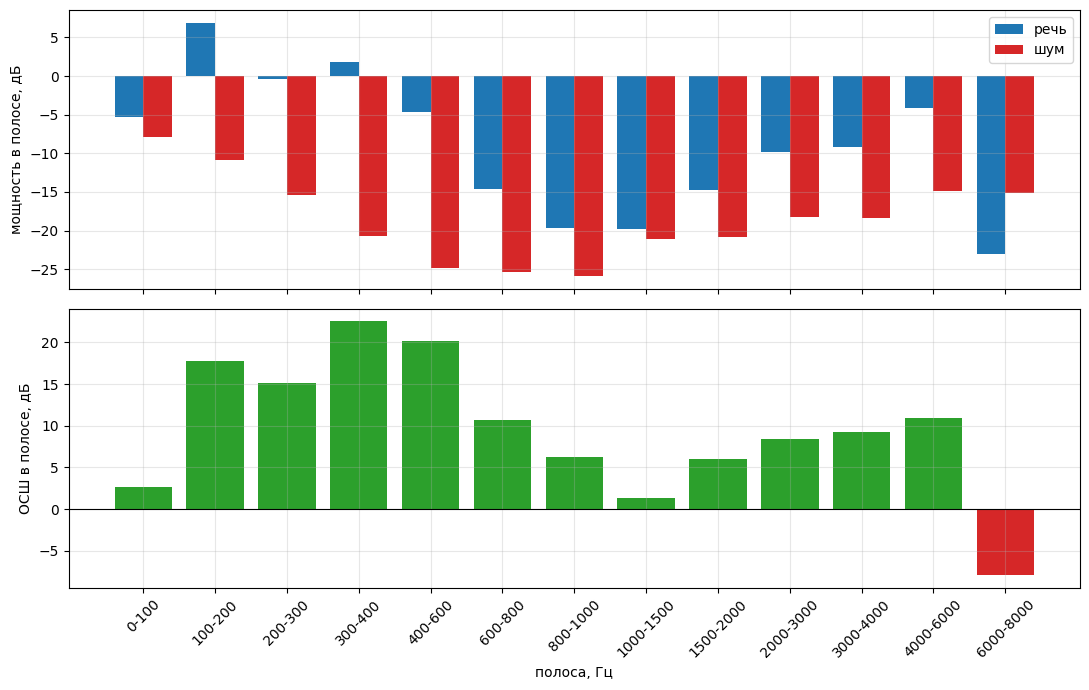

In [15]:
import json

_, times, _ = stft(mixed)
rows = band_snr_table(speech_used, noise_used, vad_frame_mask(timeline, times))
for r in rows:
    print(f"{r['band_hz'][0]:>5}-{r['band_hz'][1]:<5} Гц: речь {r['speech_db']:>6} дБ, шум {r['noise_db']:>6} дБ, ОСШ {r['snr_db']:>6} дБ")
plot_band_snr(rows, PROJECT_ROOT / "results/stage02_band_snr.png")

metrics = {name: window_metrics(w(64)) for name, w in WINDOWS.items()}
with open(PROJECT_ROOT / "results/stage02_band_snr.json", "w", encoding="utf-8") as f:
    json.dump({"snr_mix_db": 5.0, "windows": metrics, "bands": rows}, f, ensure_ascii=False, indent=2)

## Вывод

При общем ОСШ смеси $5$ дБ распределение по частоте крайне неравномерно:

1. **6000--8000 Гц: ОСШ $\approx -7{,}9$ дБ.** Речи почти нет, шум белый -- эта полоса целиком «чужая» и практически не несёт полезной информации.
2. **1000--1500 Гц: ОСШ $\approx 1{,}3$ дБ** -- самая мешающая полоса внутри речевого диапазона: речь здесь слабая (область между формантами), белый шум сравним с ней по мощности; именно здесь страдает разборчивость согласных.
3. **0--100 Гц: ОСШ $\approx 2{,}6$ дБ** -- основная гармоника гула на 90 Гц. В полосах 100--400 Гц суммарное ОСШ высокое (15--22 дБ) за счёт мощной низкочастотной речи, но гул -- узкополосный, и в бинах самих линий $90,180,270,360$ Гц локальное ОСШ значительно хуже: их можно подавить узкими режекторными/полосовыми фильтрами почти без вреда для речи (этап 5).

Итог: гармоники гула (90--360 Гц) -- узкополосная помеха, подавляемая фильтрацией; белый шум -- широкополосная, его вклад максимален там, где речь слаба (1--1,5 кГц и выше 6 кГц), и с ним работает спектральное вычитание (этап 4).